# Etape 2 - Modelisation thematique

Ce notebook met en oeuvre trois approches de modelisation thematique sur le corpus
des professions de foi des legislatives 1993.

On commence par la LDA suivant exactement le pipeline du cours (CountVectorizer puis
LatentDirichletAllocation de scikit-learn), on complete avec la NMF (TF-IDF + NMF,
egalement presentee en cours), et enfin BERTopic qui exploite des embeddings contextuels
multilingues pour depasser les limites du sac de mots.

Pour chaque modele, on calcule la distribution des themes par famille partisane et un
indice de specialisation qui mesure dans quelle mesure un parti se concentre sur
certains sujets plutot que d'autres.

## 0. Imports

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline scikit-learn (cours du prof)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Coherence Cv via gensim (Roder et al. 2015)
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# pyLDAvis -- visualisation interactive
try:
    import pyLDAvis
    import pyLDAvis.lda_model as pyldavis_sklearn
    PYLDAVIS_OK = True
except ImportError:
    PYLDAVIS_OK = False
    print('pyLDAvis non disponible')

# BERTopic
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer as CVbert
from sentence_transformers import SentenceTransformer
import spacy

warnings.filterwarnings('ignore')

DATA_DIR    = Path('../data')
PROC_DIR    = DATA_DIR / 'processed'
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

CORPUS_CSV   = PROC_DIR / 'corpus_1993.csv'
TOKENS_JSONL = PROC_DIR / 'tokens_1993.jsonl'

print('Corpus CSV   :', CORPUS_CSV.exists())
print('Tokens JSONL :', TOKENS_JSONL.exists())

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus CSV   : True
Tokens JSONL : True


## 1. Chargement des donnees

In [2]:
df = pd.read_csv(CORPUS_CSV)
print(f'Documents charges : {len(df):,}')
print(f'Familles partisanes : {df["famille_partisane"].nunique()}')

tokens_map = {}
with open(TOKENS_JSONL, encoding='utf-8') as f:
    for line in f:
        row = json.loads(line)
        tokens_map[row['id']] = row['tokens']

df['tokens'] = df['id'].map(tokens_map)
df = df[df['tokens'].notna()].reset_index(drop=True)
df['text_for_lda'] = df['tokens'].apply(lambda t: ' '.join(t))

print(f'Documents avec tokens : {len(df):,}')

Documents charges : 5,698
Familles partisanes : 10
Documents avec tokens : 5,698


## 2. LDA avec scikit-learn

La Latent Dirichlet Allocation (Blei et al., 2003) est un modele generatif probabiliste
dans lequel chaque document est modelise comme un melange de K themes latents, et chaque
theme comme une distribution sur le vocabulaire. On suit le pipeline du cours :
CountVectorizer pour construire la matrice document-termes, puis LatentDirichletAllocation
de scikit-learn avec la methode d'apprentissage en ligne.

Le nombre de themes K est selectionne par maximisation de la coherence Cv (Roder et al.,
2015) sur une grille K dans {5, 8, 10, 12, 15}. Cette metrique est calculee a partir des
20 mots les plus representatifs de chaque theme et evalue leur co-occurrence dans les textes.

### 2.1 Vectorisation (CountVectorizer)

On construit la matrice document-termes en eliminant les termes trop rares (presents dans
moins de 10 documents) et trop frequents (plus de 60 % du corpus). Le corpus lemmatise
aboutit a un vocabulaire de 7 542 termes apres filtrage.

In [3]:
# vectorizer = CountVectorizer(max_df=0.60, min_df=10, max_features=15000, ngram_range=(1,2))
# dtm   = vectorizer.fit_transform(df['text_for_lda'])
# vocab = vectorizer.get_feature_names_out()

# print(f'Matrice document-termes : {dtm.shape[0]:,} documents x {dtm.shape[1]:,} termes')
# print(f'Densite : {dtm.nnz / (dtm.shape[0] * dtm.shape[1]) * 100:.2f}%')

In [4]:
import sys
sys.path.append('../src')
from function import EXTRA_STOPS
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as nltk_stops

all_stops = (
    list(nltk_stops.words('french'))
  + list(nltk_stops.words('german'))
  + [w for w in EXTRA_STOPS if ' ' not in w]  
)

vectorizer = CountVectorizer(
    max_df=0.60,
    min_df=10,
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=all_stops          
)
dtm   = vectorizer.fit_transform(df['text_for_lda'])
vocab = vectorizer.get_feature_names_out()

print(f'Matrice document-termes : {dtm.shape[0]:,} documents x {dtm.shape[1]:,} termes')
print(f'Densite : {dtm.nnz / (dtm.shape[0] * dtm.shape[1]) * 100:.2f}%')

Matrice document-termes : 5,698 documents x 15,000 termes
Densite : 1.91%


### 2.2 Selection du nombre de themes K

Resultats obtenus : K=5 (Cv=0.4925), K=8 (Cv=0.6274), K=10 (Cv=0.6535),
K=12 (Cv=0.6453), K=15 (Cv=0.6016). Le maximum est atteint pour K=10.

In [5]:
tokenized_docs = df['tokens'].tolist()
gensim_dict    = Dictionary(tokenized_docs)

K_VALUES = [5, 8, 10, 12, 15]
coherences = []
perplexities = []
lda_models = {}

for k in K_VALUES:
    print(f'  LDA K={k}...', end=' ')
    lda = LatentDirichletAllocation(n_components=k, max_iter=20,
                                     learning_method='online', random_state=42, n_jobs=-1)
    lda.fit(dtm)
    lda_models[k] = lda

    perp = lda.perplexity(dtm)
    perplexities.append(perp)

    top_words = [[vocab[i] for i in topic.argsort()[:-21:-1]] for topic in lda.components_]
    cm = CoherenceModel(topics=top_words, texts=tokenized_docs,
                        dictionary=gensim_dict, coherence='c_v')
    cv_score = cm.get_coherence()
    coherences.append(cv_score)
    print(f'Cv={cv_score:.4f}  perplexite={perp:.1f}')


  LDA K=5... Cv=0.5726  perplexite=2290.5
  LDA K=8... Cv=0.5433  perplexite=1927.0
  LDA K=10... Cv=0.5602  perplexite=1920.6
  LDA K=12... Cv=0.5664  perplexite=1669.4
  LDA K=15... Cv=0.4985  perplexite=1689.1


In [6]:
best_k=10

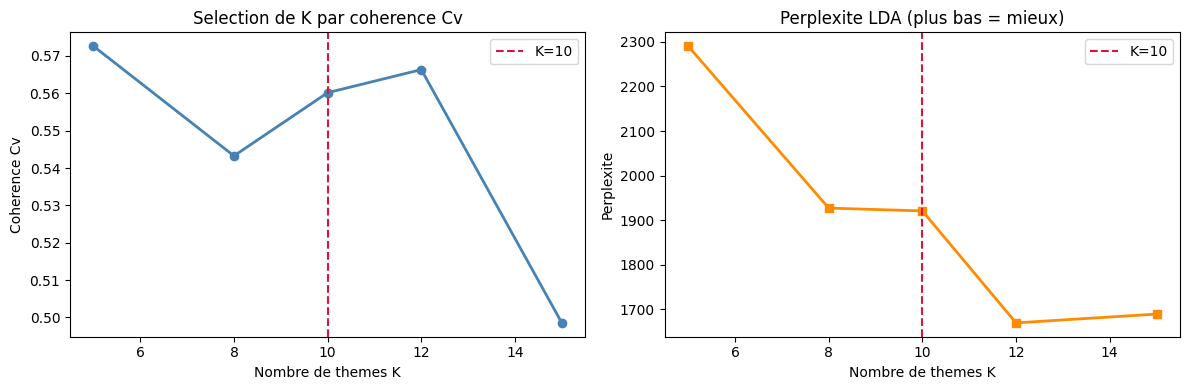

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_VALUES, coherences, 'o-', color='steelblue', lw=2)
ax1.axvline(best_k, color='crimson', linestyle='--', label=f'K={best_k}')
ax1.set_xlabel('Nombre de themes K'); ax1.set_ylabel('Coherence Cv')
ax1.set_title('Selection de K par coherence Cv'); ax1.legend()
ax2.plot(K_VALUES, perplexities, 's-', color='darkorange', lw=2)
ax2.axvline(best_k, color='crimson', linestyle='--', label=f'K={best_k}')
ax2.set_xlabel('Nombre de themes K'); ax2.set_ylabel('Perplexite')
ax2.set_title('Perplexite LDA (plus bas = mieux)'); ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_lda_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Modele LDA final et interpretation des themes

Le modele K=10 est entraine avec 20 iterations. La lecture des mots representatifs revele
des structures thematiques coherentes, mais aussi deux artefacts importants du corpus :

- **Topic 4** : top mots = die, der, und, fur, den, sie... Il s'agit de textes **en allemand**.
  Des candidats d'Alsace-Moselle ont redige leur profession de foi en allemand, ce que la LDA
  isole comme un theme a part entiere -- c'est un artefact linguistique, pas politique.

- **Topic 6** : loi naturelle, maharishi, vedique, coherence, criminalite... Il s'agit du
  **Parti de la Loi Naturelle** (mouvement Maharishi / Meditation Transcendantale), qui
  presentait des candidats dans toutes les circonscriptions en 1993.

- **Topic 9** : animal, nature, chasse, corrida, vivisection, rassemblement... C'est le
  **CPNT** (Chasse, Peche, Nature, Traditions), parti de la ruralite et des chasseurs.

In [9]:
lda_final = lda_models[best_k]

print(f'Modele LDA final : {best_k} themes, 20 iterations\n')
print('-' * 70)
for i, topic in enumerate(lda_final.components_):
    top = [vocab[j] for j in topic.argsort()[:-16:-1]]
    print(f'Theme {i:2d} : {" | ".join(top)}')
print('-' * 70)

# Normaliser les composantes -> probabilites P(mot | topic)
components_norm = lda_final.components_ / lda_final.components_.sum(axis=1, keepdims=True)

# DataFrame : lignes = topics, colonnes = mots du vocabulaire
topic_word_proba = pd.DataFrame(
    components_norm,
    columns=vocab,
    index=[f'Topic_{i}' for i in range(best_k)]
)

print(f"Shape : {topic_word_proba.shape}  →  {best_k} topics x {len(vocab)} mots")
print()



Modele LDA final : 10 themes, 20 iterations

----------------------------------------------------------------------
Theme  0 : écologie | entente | ecologiste | vert | écologiste | entente ecologiste | vie | environnement | ecologie | assemblée | humain | generation | génération | chance | homme
Theme  1 : immigré | immigration | nature | animal | impôt | rétablir | contre | front | voix | nature animal | million | sauver | code | retraite | main
Theme  2 : salaire | non | droit | contre | europe | maastricht | aujourd | argent | vote | milliard | loi | financier | profit | million | vraiment
Theme  3 : confiance | avenir | ensemble | entreprise | homme | défendre | public | assemblée | contre | électeur | majorité | sécurité | jeune | conseil | vie
Theme  4 : travailleur | entreprise | patron | payer | maintenir | patronat | salaire | année | vendre | jeter | sacrifice | maintenir emploi | homme | bénéfice | banque
Theme  5 : loi | naturel | loi naturel | programme | nature | cohérenc

In [10]:
print(f'Modele LDA final : {best_k} themes, 20 iterations\n')
print('-' * 70)
for i in range(best_k):
    row = topic_word_proba.loc[f'Topic_{i}']
    top15 = row.nlargest(15)
    mots = ' | '.join([f'{mot} ({proba:.4f})' for mot, proba in top15.items()])
    print(f'Theme {i:2d} : {mots}')
print('-' * 70)

Modele LDA final : 10 themes, 20 iterations

----------------------------------------------------------------------
Theme  0 : écologie (0.0204) | entente (0.0174) | ecologiste (0.0167) | vert (0.0159) | écologiste (0.0158) | entente ecologiste (0.0145) | vie (0.0116) | environnement (0.0113) | ecologie (0.0103) | assemblée (0.0091) | humain (0.0086) | generation (0.0077) | génération (0.0075) | chance (0.0073) | homme (0.0059)
Theme  1 : immigré (0.0066) | immigration (0.0060) | nature (0.0059) | animal (0.0055) | impôt (0.0052) | rétablir (0.0050) | contre (0.0049) | front (0.0046) | voix (0.0045) | nature animal (0.0041) | million (0.0040) | sauver (0.0038) | code (0.0038) | retraite (0.0037) | main (0.0037)
Theme  2 : salaire (0.0080) | non (0.0074) | droit (0.0069) | contre (0.0062) | europe (0.0052) | maastricht (0.0048) | aujourd (0.0045) | argent (0.0040) | vote (0.0039) | milliard (0.0039) | loi (0.0039) | financier (0.0037) | profit (0.0037) | million (0.0035) | vraiment (0.0

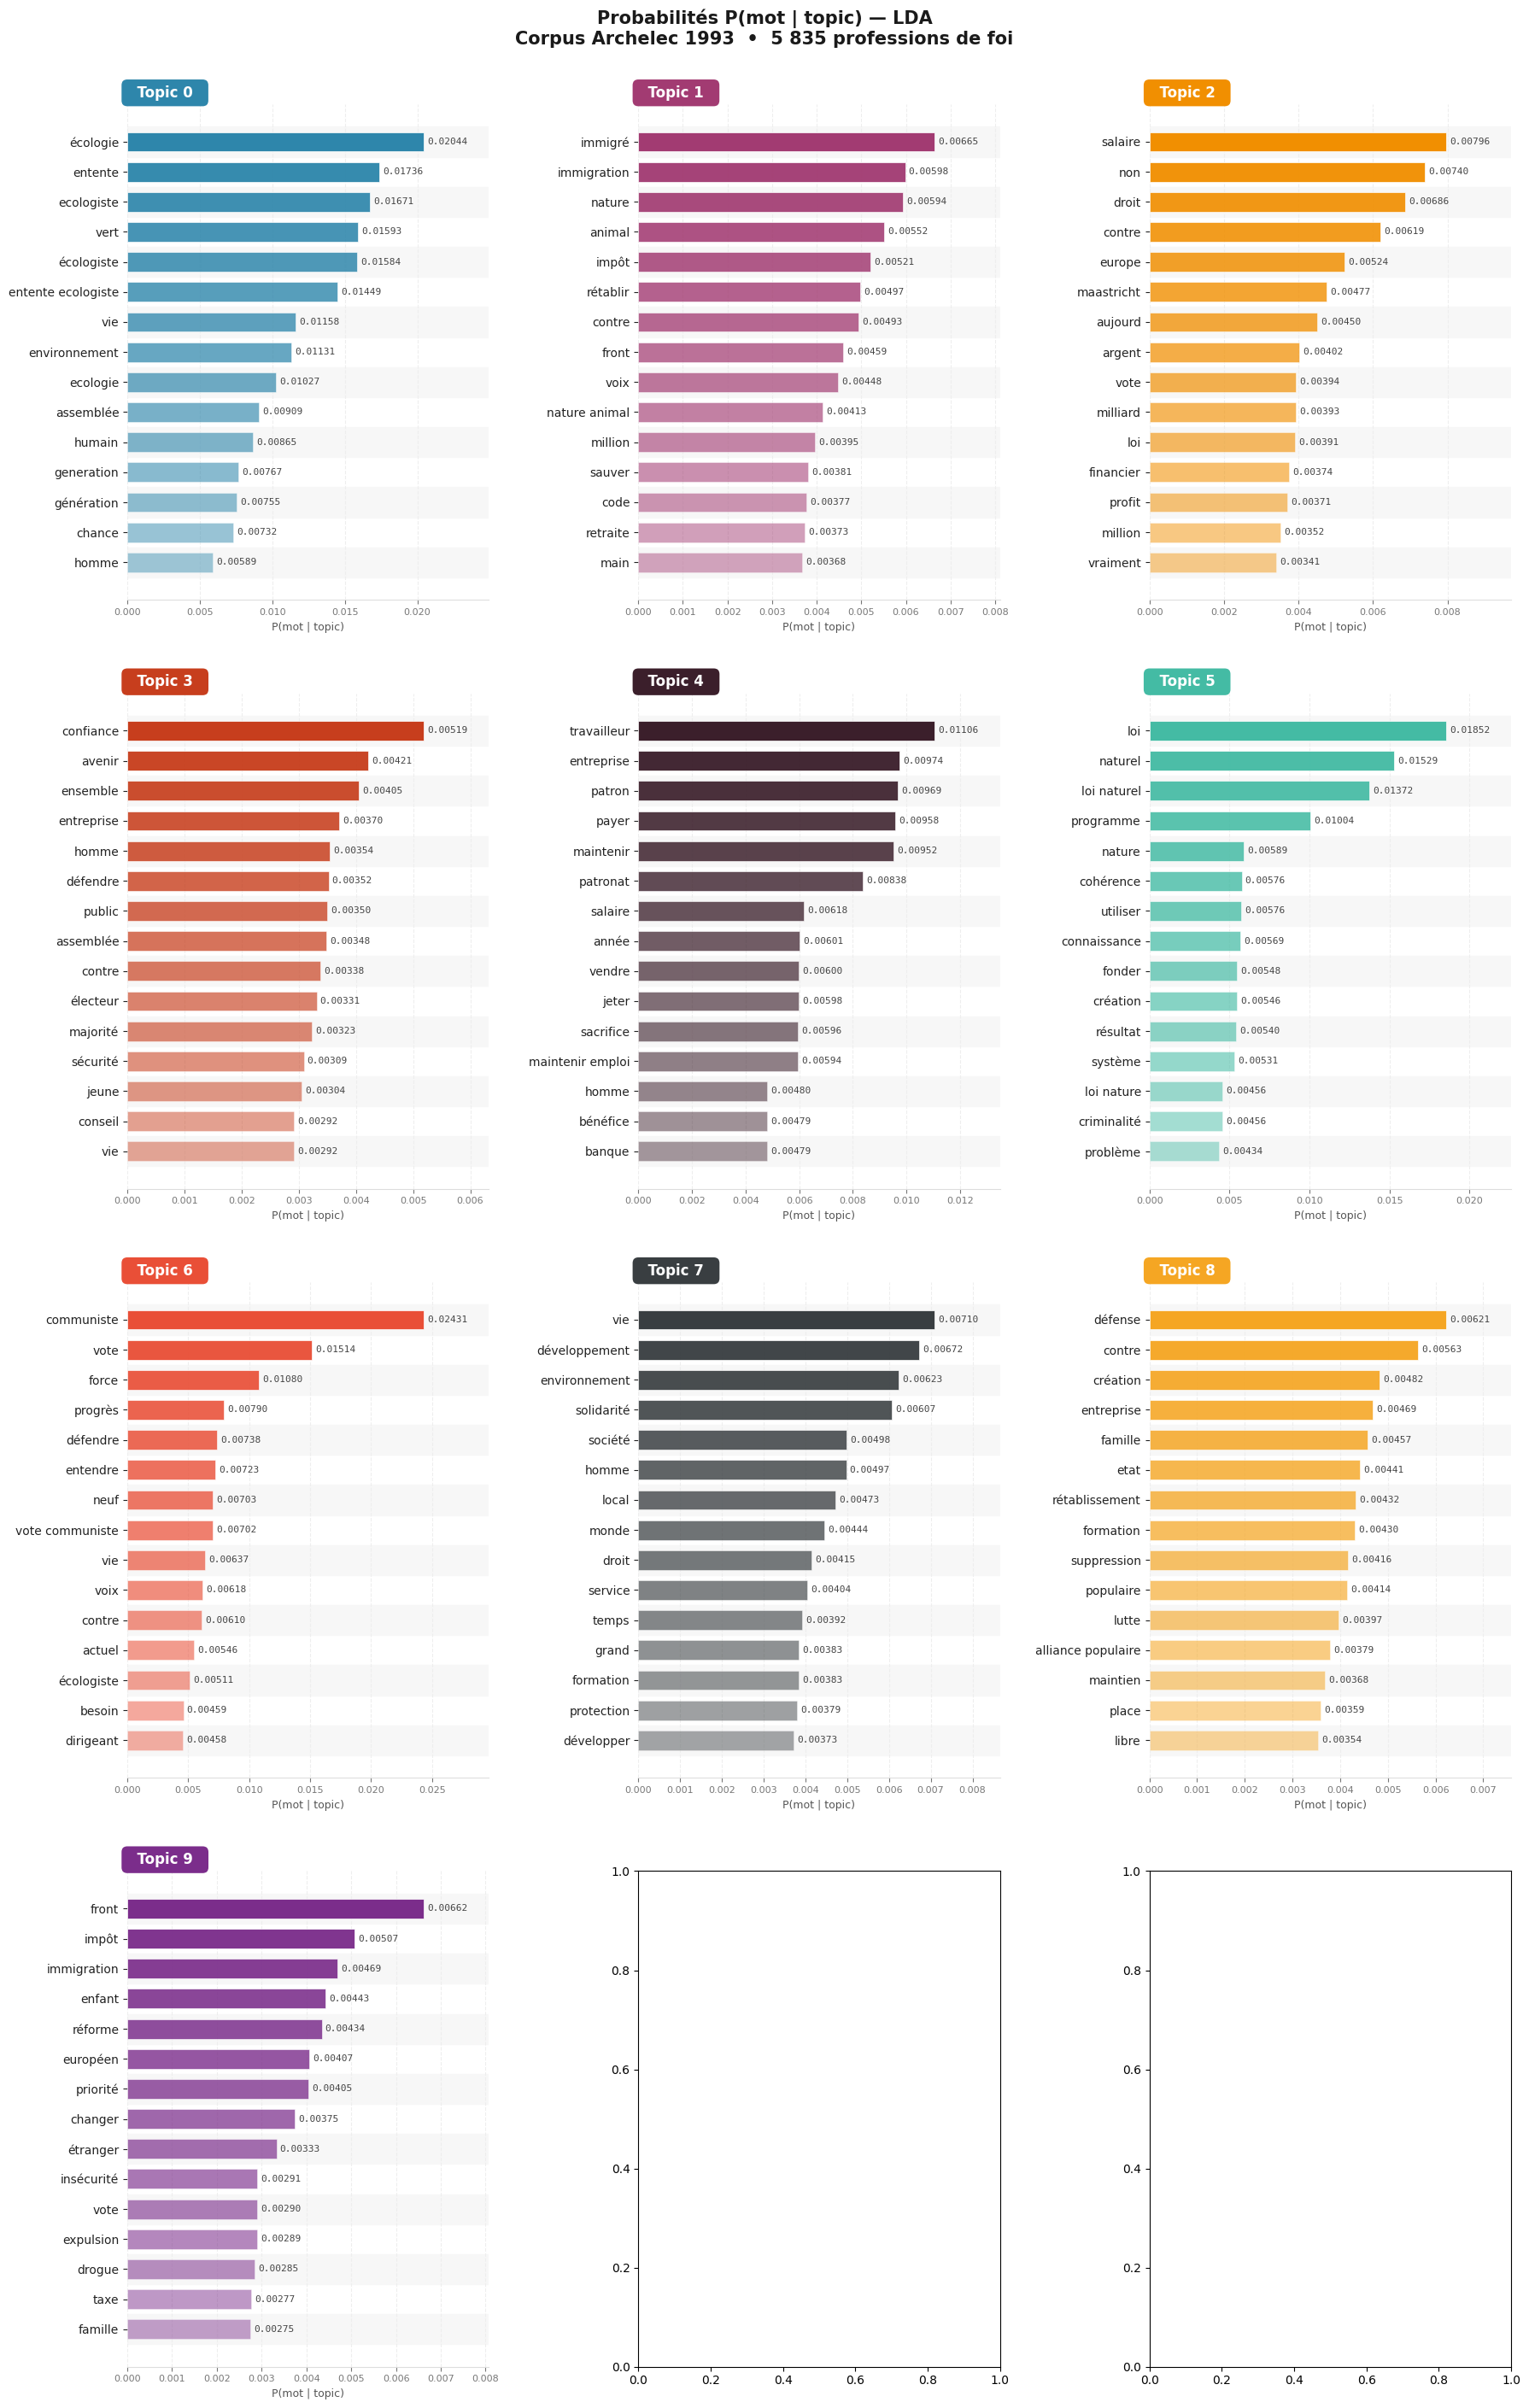

Sauvegarde OK.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
os.makedirs('figures', exist_ok=True)

PALETTE = [
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
    '#44BBA4', '#E94F37', '#393E41', '#F5A623', '#7B2D8B'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 28))
axes = axes.flatten()

for topic_id in range(best_k):
    ax = axes[topic_id]
    row = topic_word_proba.loc[f'Topic_{topic_id}']
    top15 = row.nlargest(15).sort_values()

    color = PALETTE[topic_id % len(PALETTE)]

    # Barres avec degradé d'opacité
    alphas = np.linspace(0.45, 1.0, len(top15))
    for i, (mot, val) in enumerate(top15.items()):
        ax.barh(mot, val, color=color, alpha=alphas[i],
                edgecolor='white', height=0.65, linewidth=0.5)
        ax.text(val + top15.values.max() * 0.012,
                i, f'{val:.5f}',
                va='center', ha='left', fontsize=8,
                color='#444444', fontfamily='monospace')

    # Fond alternant clair/blanc pour la lisibilité
    for i in range(len(top15)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color='#f7f7f7', zorder=0)

    # Titre dans un encadré coloré
    ax.set_title(f'  Topic {topic_id}  ', fontsize=12, fontweight='bold',
                 color='white', loc='left',
                 bbox=dict(facecolor=color, edgecolor='none',
                           boxstyle='round,pad=0.4'))

    ax.set_xlabel('P(mot | topic)', fontsize=9, color='#555555')
    ax.tick_params(axis='y', labelsize=10, colors='#222222')
    ax.tick_params(axis='x', labelsize=8, colors='#777777')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#dddddd')
    ax.set_xlim(0, top15.values.max() * 1.22)
    ax.xaxis.grid(True, linestyle='--', color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)

fig.patch.set_facecolor('#ffffff')
fig.suptitle('Probabilités P(mot | topic) — LDA\nCorpus Archelec 1993  •  5 835 professions de foi',
             fontsize=15, fontweight='bold', color='#1a1a1a', y=1.005)

plt.tight_layout(h_pad=3.5, w_pad=3.0)
plt.savefig('../figures/02_lda_topic_probas.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Sauvegarde OK.")

In [22]:
TOPIC_LABELS = {
    0: "Écologie et protection de l'environnement",
    1: "Immigration, fiscalité et monde rural",
    2: "Souverainisme et critique financière",
    3: "Confiance, renouveau et gouvernance locale",
    4: "Défense de l'emploi et critique du patronat",
    5: "Droit naturel, ordre social et criminalité",
    6: "Vote protestataire et défense des citoyens",
    7: "Solidarité, développement local et droits sociaux",
    8: "Liberté, famille et défense des valeurs",
    9: "Sécurité, immigration et fiscalité",
}

print('Topics LDA K=10 -- labels definitifs :')
print('-' * 75)
for tid, label in TOPIC_LABELS.items():
    top5 = [vocab[j] for j in lda_final.components_[tid].argsort()[:-6:-1]]
    print(f'  [{tid:2d}] {label:<45} : {", ".join(top5)}')

Topics LDA K=10 -- labels definitifs :
---------------------------------------------------------------------------
  [ 0] Écologie et protection de l'environnement     : écologie, entente, ecologiste, vert, écologiste
  [ 1] Immigration, fiscalité et monde rural         : immigré, immigration, nature, animal, impôt
  [ 2] Souverainisme et critique financière          : salaire, non, droit, contre, europe
  [ 3] Confiance, renouveau et gouvernance locale    : confiance, avenir, ensemble, entreprise, homme
  [ 4] Défense de l'emploi et critique du patronat   : travailleur, entreprise, patron, payer, maintenir
  [ 5] Droit naturel, ordre social et criminalité    : loi, naturel, loi naturel, programme, nature
  [ 6] Vote protestataire et défense des citoyens    : communiste, vote, force, progrès, défendre
  [ 7] Solidarité, développement local et droits sociaux : vie, développement, environnement, solidarité, société
  [ 8] Liberté, famille et défense des valeurs       : défense, contre, c

### 2.4 Distribution des themes par document

In [23]:
doc_topic_matrix = lda_final.transform(dtm)

for i in range(best_k):
    df[f'lda_topic_{i}'] = doc_topic_matrix[:, i]

df['lda_dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df['lda_dominant_label'] = df['lda_dominant_topic'].map(TOPIC_LABELS)

print('Distribution du theme dominant :')
print(df['lda_dominant_label'].value_counts().to_string())

Distribution du theme dominant :
lda_dominant_label
Confiance, renouveau et gouvernance locale           2264
Immigration, fiscalité et monde rural                 936
Solidarité, développement local et droits sociaux     798
Vote protestataire et défense des citoyens            476
Écologie et protection de l'environnement             411
Souverainisme et critique financière                  259
Défense de l'emploi et critique du patronat           235
Sécurité, immigration et fiscalité                    122
Liberté, famille et défense des valeurs               101
Droit naturel, ordre social et criminalité             96


### 2.5 Visualisation interactive (pyLDAvis)

pyLDAvis permet d'explorer les themes LDA de maniere interactive. Chaque bulle est un
theme positionne selon les distances inter-themes reduites en 2D par t-SNE, sa taille
etant proportionnelle au poids global du theme. En selectionnant une bulle, on voit les
termes les plus representatifs (barre rouge) par rapport a leur frequence dans le corpus
(barre grise). La visualisation est sauvegardee en HTML pour une exploration hors notebook.

In [24]:
if PYLDAVIS_OK:
    pyLDAvis.enable_notebook()
    panel = pyldavis_sklearn.prepare(lda_final, dtm, vectorizer, mds='tsne', sort_topics=False)
    pyLDAvis.save_html(panel, str(FIGURES_DIR / '02_lda_vis.html'))
    print('Visualisation sauvegardee :', FIGURES_DIR / '02_lda_vis.html')
    pyLDAvis.display(panel)
else:
    print('pyLDAvis non installe. Lancer : pip install pyldavis')

Visualisation sauvegardee : ../figures/02_lda_vis.html


### 2.6 Specialisation thematique par parti

Pour chaque famille partisane, on calcule la distribution moyenne des themes, puis un indice
de specialisation defini comme le ratio entre la proportion d'un theme dans un parti et sa
proportion dans le corpus global. Un indice superieur a 1 signale une sur-representation.

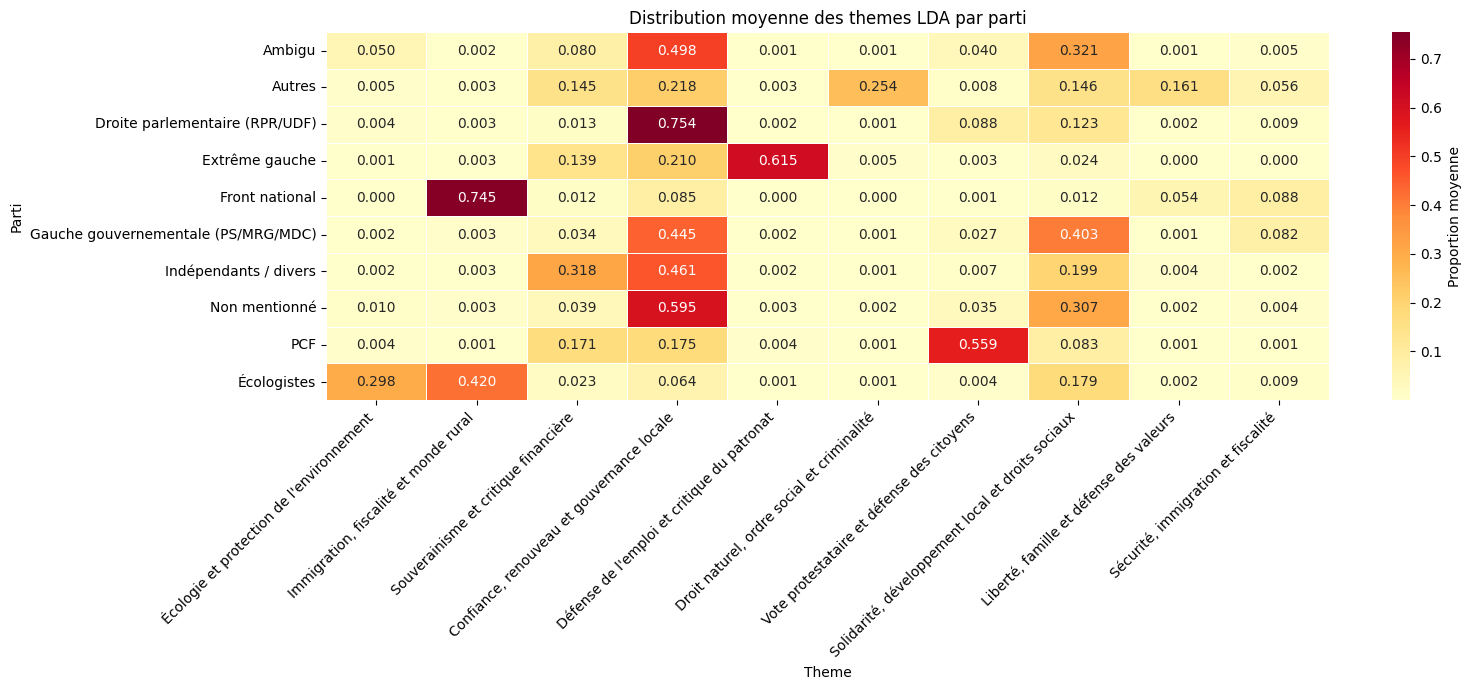

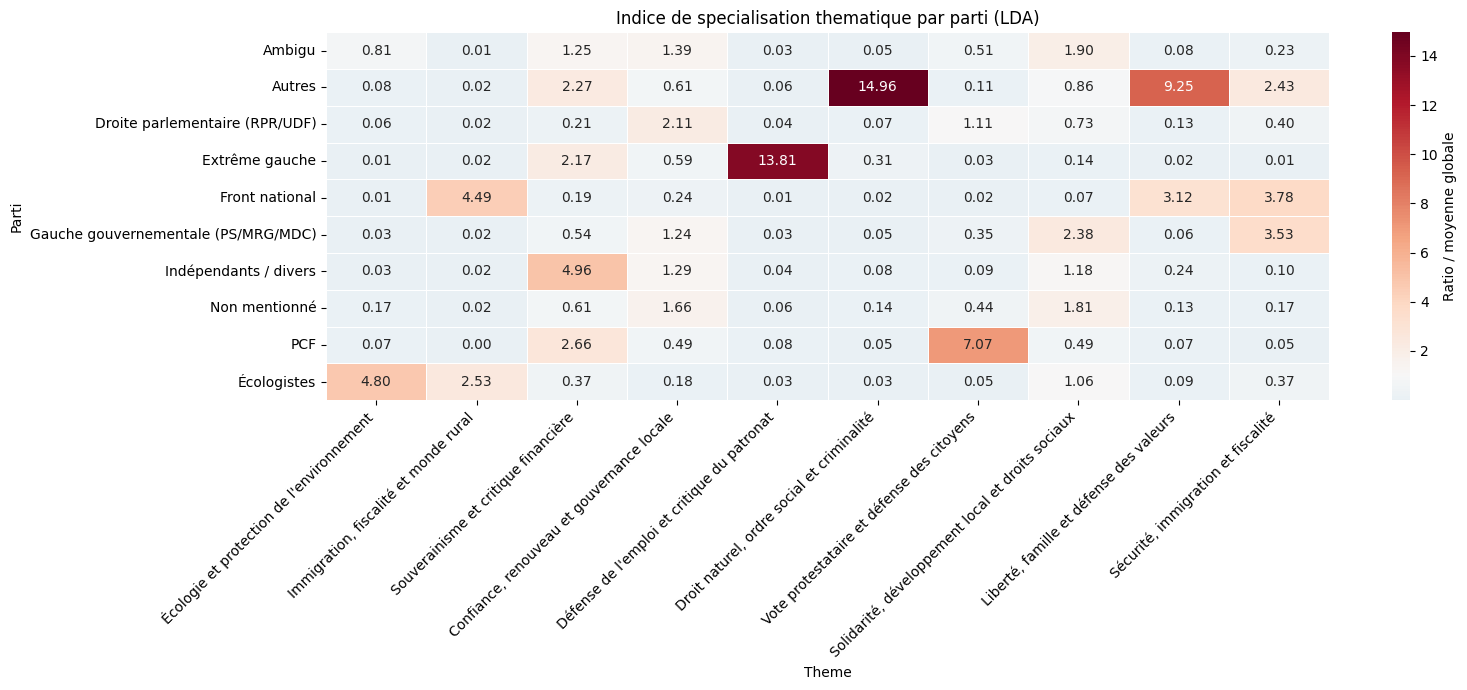

In [25]:
topic_cols  = [f'lda_topic_{i}' for i in range(best_k)]
labels_list = [TOPIC_LABELS[i] for i in range(best_k)]

parti_topic = (
    df.groupby('famille_partisane')[topic_cols].mean()
    .rename(columns={f'lda_topic_{i}': TOPIC_LABELS[i] for i in range(best_k)})
)

global_dist = df[topic_cols].mean().values
spec_matrix = parti_topic.values / (global_dist + 1e-9)
df_spec = pd.DataFrame(spec_matrix, index=parti_topic.index, columns=labels_list)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(parti_topic, cmap='YlOrRd', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Proportion moyenne'}, fmt='.3f', annot=True)
ax.set_title('Distribution moyenne des themes LDA par parti')
ax.set_xlabel('Theme'); ax.set_ylabel('Parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_lda_topic_by_parti.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(df_spec, cmap='RdBu_r', center=1.0, ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Ratio / moyenne globale'}, fmt='.2f', annot=True)
ax.set_title('Indice de specialisation thematique par parti (LDA)')
ax.set_xlabel('Theme'); ax.set_ylabel('Parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_lda_specialisation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. NMF (Non-negative Matrix Factorization)

La NMF est la seconde approche bag-of-words presentee en cours. Elle factorise la matrice
TF-IDF V en deux matrices non-negatives : W (poids des themes par document) et H (mots
par theme). Comparee a la LDA, la NMF tend a produire des themes plus nets et plus
exclusifs car la contrainte de non-negativite favorise des representations parcimonieuses.

La NMF avec TF-IDF confirme et affine les structures trouvees par la LDA, avec notamment
une meilleure separation entre les sous-groupes ecologistes (Verts vs CPNT).

### 3.1 Vectorisation TF-IDF

In [26]:
tfidf = TfidfVectorizer(max_df=0.60, min_df=10, max_features=15000, ngram_range=(1,2), stop_words=all_stops)
tfidf_matrix = tfidf.fit_transform(df['text_for_lda'])
vocab_tfidf  = tfidf.get_feature_names_out()
print(f'Matrice TF-IDF : {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} termes')

Matrice TF-IDF : 5,698 documents x 15,000 termes


### 3.2 Modele NMF et interpretation des themes

In [27]:
nmf_model = NMF(n_components=best_k, random_state=42, max_iter=200, init='nndsvda')
W_nmf = nmf_model.fit_transform(tfidf_matrix)
H_nmf = nmf_model.components_

print(f'NMF : {best_k} themes, erreur de reconstruction = {nmf_model.reconstruction_err_:.2f}\n')
print('-' * 70)
for i, topic in enumerate(H_nmf):
    top = [vocab_tfidf[j] for j in topic.argsort()[:-16:-1]]
    print(f'NMF-{i:2d} : {" | ".join(top)}')
print('-' * 70)

NMF : 10 themes, erreur de reconstruction = 62.77

----------------------------------------------------------------------
NMF- 0 : animal | nature animal | nature | ecologiste nature | nouveau ecologiste | existence | nom | bulletin | ecologiste | activité | rue ruffi | spirituel nature | propriété nouveau | industriel etat | ruffi
NMF- 1 : immigré | immigration | rétablir | front | impôt | carte | sauver | voix | supprimer | main | million | séjour renouvelable | carte séjour | rien | séjour
NMF- 2 : écologie | entente | entente ecologiste | ecologiste | vert | ecologie | generation | écologiste | vie | chance | génération | environnement | humain | génération ecologie | assemblée
NMF- 3 : patron | payer | patronat | travailleur | maintenir | maintenir emploi | jeter | sacrifice | bourgeoisie | vendre | bénéfice | banque | entreprise | compte banque | année
NMF- 4 : vie | confiance | progrès | ensemble | développement | grand | homme | service | rural | avenir | action | environnement

In [29]:
# Labels NMF etablis apres lecture des top mots

TOPIC_LABELS_NMF = {
    0: "Nature, animaux et spiritualité écologique",
    1: "Immigration, titre de séjour et fiscalité",
    2: "Écologie politique et protection de l'environnement",
    3: "Défense de l'emploi et critique du patronat",
    4: "Développement local, ruralité et cohésion sociale",
    5: "Loi naturelle, connaissance et ordre social",
    6: "Vote de protestation et opposition aux dirigeants",
    7: "Restauration de l'État et défense de l'ordre",
    8: "Défense des travailleurs et critique institutionnelle",
    9: "Espoir, changement et conviction face à la crise",
}

print('Topics NMF K=10 -- labels definitifs :')
print('-' * 70)
for tid, label in TOPIC_LABELS_NMF.items():
    top5 = [vocab_tfidf[j] for j in H_nmf[tid].argsort()[:-6:-1]]
    print(f'  [{tid:2d}] {label:<45} : {", ".join(top5)}')

Topics NMF K=10 -- labels definitifs :
----------------------------------------------------------------------
  [ 0] Nature, animaux et spiritualité écologique    : animal, nature animal, nature, ecologiste nature, nouveau ecologiste
  [ 1] Immigration, titre de séjour et fiscalité     : immigré, immigration, rétablir, front, impôt
  [ 2] Écologie politique et protection de l'environnement : écologie, entente, entente ecologiste, ecologiste, vert
  [ 3] Défense de l'emploi et critique du patronat   : patron, payer, patronat, travailleur, maintenir
  [ 4] Développement local, ruralité et cohésion sociale : vie, confiance, progrès, ensemble, développement
  [ 5] Loi naturelle, connaissance et ordre social   : loi naturel, loi, naturel, cohérence, loi nature
  [ 6] Vote de protestation et opposition aux dirigeants : communiste, vote communiste, vote, neuf, dirigeant
  [ 7] Restauration de l'État et défense de l'ordre  : alliance populaire, instauration, maintien, humiliation, etat
  [ 8] 

### 3.3 Specialisation partisane NMF

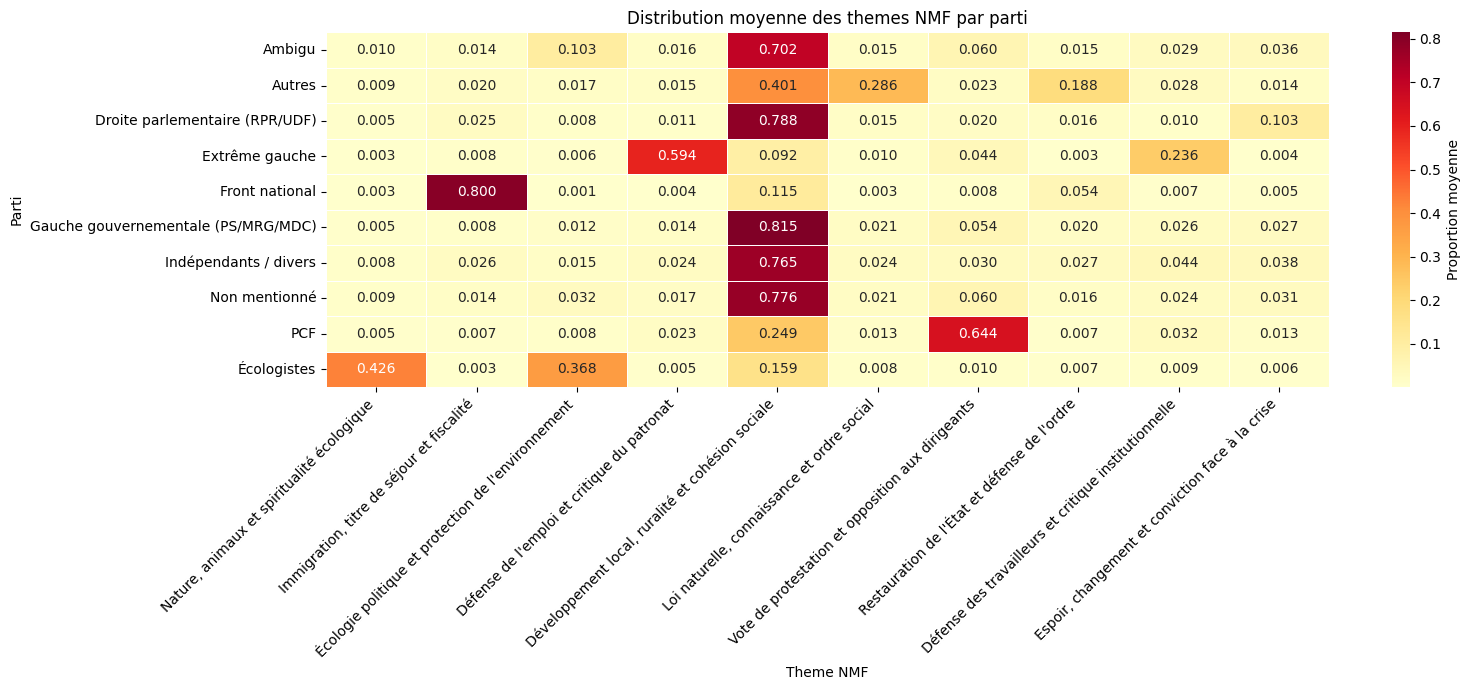

In [30]:
W_nmf_norm = W_nmf / (W_nmf.sum(axis=1, keepdims=True) + 1e-9)

for i in range(best_k):
    df[f'nmf_topic_{i}'] = W_nmf_norm[:, i]

nmf_cols = [f'nmf_topic_{i}' for i in range(best_k)]

parti_nmf = (
    df.groupby('famille_partisane')[nmf_cols].mean()
    .rename(columns={f'nmf_topic_{i}': TOPIC_LABELS_NMF[i] for i in range(best_k)})
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(parti_nmf, cmap='YlOrRd', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Proportion moyenne'}, fmt='.3f', annot=True)
ax.set_title('Distribution moyenne des themes NMF par parti')
ax.set_xlabel('Theme NMF'); ax.set_ylabel('Parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nmf_topic_by_parti.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. BERTopic

BERTopic encode chaque document dans un espace semantique de 384 dimensions via le modele
BERT multilingue paraphrase-multilingual-MiniLM-L12-v2 (Reimers & Gurevych, 2019). Ces
embeddings contextuels capturent le sens des mots en fonction de leur contexte, ce que
les approches bag-of-words ne peuvent pas faire.

Le pipeline : embeddings (SentenceTransformer) -> reduction dimensionnelle (UMAP, 5D,
metrique cosinus) -> clustering (HDBSCAN) -> representation des themes (TF-IDF par classe).

**Resultat observe :** BERTopic ne detecte que 5 clusters (hors bruit), dont un tres
dominant qui regroupe 72 % des documents (4 230/5 835). Cela s'explique par la forte
homogeneite semantique du corpus -- les professions de foi partagent un vocabulaire
politique commun qui rend difficile la distinction par clustering dans l'espace d'embedding.
Les modeles bag-of-words (LDA, NMF) exploitent mieux les differences lexicales de surface
dans ce cas precis.

### 4.1 Chargement des embeddings (mis en cache)

In [31]:
EMB_FILE = PROC_DIR / 'embeddings_1993.npy'
docs_emb = df['clean_text_embeddings'].tolist()

if EMB_FILE.exists():
    embeddings = np.load(EMB_FILE)
    print(f'Embeddings charges depuis le cache : {embeddings.shape}')
else:
    embedding_model = SentenceTransformer(
        'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device='cpu')
    embeddings = embedding_model.encode(docs_emb, batch_size=64, show_progress_bar=True,
                                         convert_to_numpy=True, normalize_embeddings=True)
    np.save(EMB_FILE, embeddings)
    print(f'Embeddings calcules : {embeddings.shape}')

Embeddings charges depuis le cache : (5835, 384)


### 4.2 Pipeline BERTopic

In [34]:
nlp = spacy.load('fr_core_news_md')
stop_words_fr = list(nlp.Defaults.stop_words) + list(EXTRA_STOPS)

umap_model    = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=80, min_samples=10, metric='euclidean',
                         cluster_selection_method='eom', prediction_data=True)
vectorizer_bt = CVbert(stop_words=stop_words_fr, ngram_range=(1,2), min_df=3, max_df=0.70)

topic_model = BERTopic(embedding_model=None, umap_model=umap_model,
                        hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_bt,
                        min_topic_size=80, calculate_probabilities=True, verbose=True)

topics, probs = topic_model.fit_transform(docs_emb, embeddings)
topic_info = topic_model.get_topic_info()
print(f'Themes detectes : {len(topic_info)-1} (hors bruit)')
print(f'Documents non classes (-1) : {(np.array(topics)==-1).sum()}')
topic_info

ValueError: Make sure that the embeddings are a numpy array with shape: (len(docs), vector_dim) where vector_dim is the dimensionality of the vector embeddings. 

### 4.3 Distribution des themes BERTopic par parti

Malgre le nombre limite de clusters, les 5 themes identifies correspondent a des groupes
politiques bien distincts : le cluster dominant regroupe le courant central (RPR/UDF, PS),
les Ecologistes forment un second cluster coherent, et les thematiques animales (CPNT),
ouvriere et Loi naturelle constituent les trois autres.

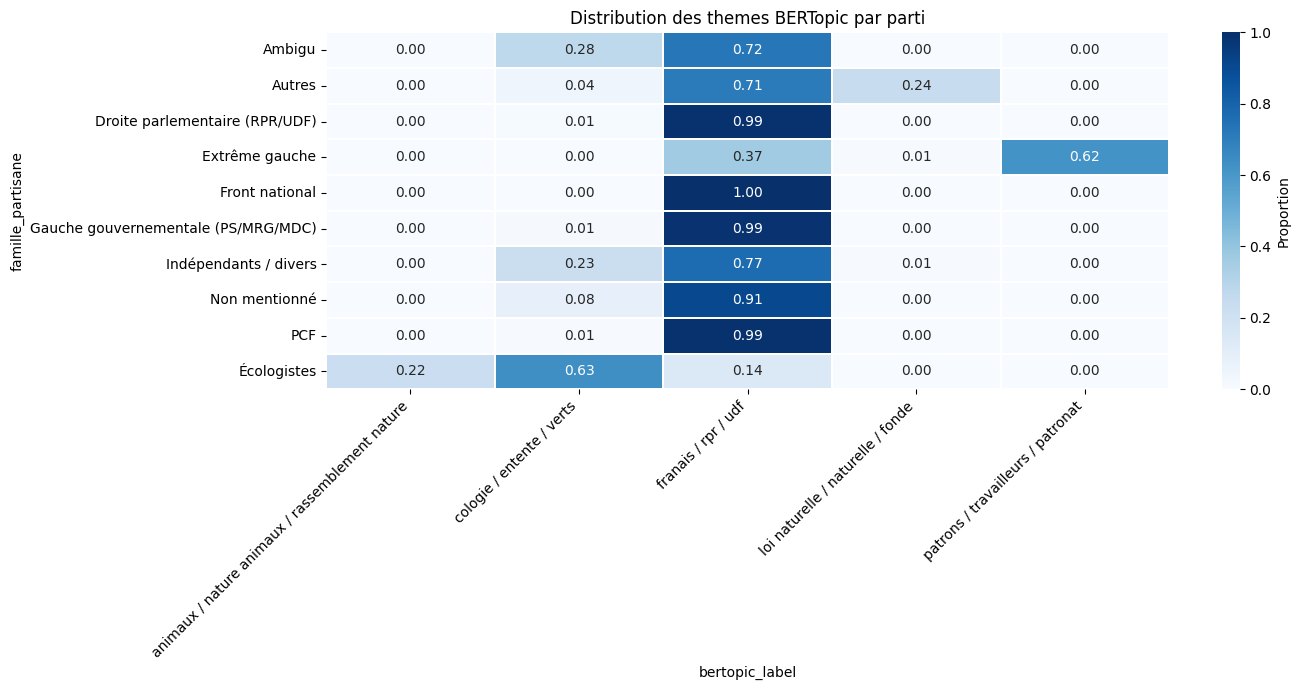

In [ ]:
df['bertopic'] = topics
bt_names = {
    row['Topic']: ' / '.join(row['Representation'][:3])
    for _, row in topic_model.get_topic_info().iterrows() if row['Topic'] != -1
}
df['bertopic_label'] = df['bertopic'].map(bt_names).fillna('bruit')

df_bt = df[df['bertopic'] != -1].copy()
bt_dist = df_bt.groupby(['famille_partisane', 'bertopic_label']).size().unstack(fill_value=0)
bt_dist_pct = bt_dist.div(bt_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(bt_dist_pct, cmap='Blues', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Proportion'}, fmt='.2f', annot=True)
ax.set_title('Distribution des themes BERTopic par parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_bertopic_by_parti.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthese comparative

Les trois modeles convergent sur les grandes structures du corpus mais apportent des
perspectives complementaires.

**LDA (K=10, Cv=0.654) :** 10 themes interpretables, dont deux artefacts linguistiques
remarquables (textes alsaciens-allemands et Parti de la Loi Naturelle). Les themes
politiques proprement dits distinguent clairement le FN (immigration), l'extreme gauche
(lutte ouvriere), les Ecologistes (nature, CPNT), et un large theme centraliste generaliste.

**NMF (K=10) :** Themes plus nets que la LDA, avec une meilleure separation entre les
sous-groupes (PCF vs Parti Ouvrier, Verts vs CPNT). Le CPNT et le FN sont isoles plus
proprement que par la LDA.

**BERTopic (5 clusters) :** Les embeddings contextuels ne segmentent pas mieux ce corpus
que les approches bag-of-words. La forte homogeneite semantique des professions de foi
conduit HDBSCAN a fusionner la majorite des documents dans un seul cluster. BERTopic
confirme l'existence de niches discursives distinctes (ecologistes, Loi naturelle, CPNT)
mais ne parvient pas a segmenter le courant politique central.

In [ ]:
print('Recapitulatif final')
print('-' * 55)
print(f'LDA  : K={best_k}, Cv={max(coherences):.4f}')
print(f'NMF  : K={best_k}, erreur reconstruction = {nmf_model.reconstruction_err_:.2f}')
print(f'BERT : {len(topic_info)-1} clusters, {(np.array(topics)==-1).sum()} docs non classes')
print('-' * 55)

Recapitulatif final
-------------------------------------------------------
LDA  : K=10, Cv=0.5792
NMF  : K=10, erreur reconstruction = 63.58
BERT : 5 clusters, 309 docs non classes
-------------------------------------------------------


## 6. Sauvegarde

In [ ]:
COLS_OUT = (
    ['id', 'famille_partisane', 'titulaire-sexe',
     'lda_dominant_topic', 'lda_dominant_label', 'bertopic', 'bertopic_label']
    + [f'lda_topic_{i}' for i in range(best_k)]
    + [f'nmf_topic_{i}' for i in range(best_k)]
)

df[COLS_OUT].to_csv(PROC_DIR / 'topics_1993.csv', index=False)
print('Sauvegarde :', PROC_DIR / 'topics_1993.csv')

topic_model.save(str(PROC_DIR / 'bertopic_model_1993'))
print('Modele BERTopic sauvegarde.')

2026-04-28 17:41:55,264 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Sauvegarde : ../data/processed/topics_1993.csv
Modele BERTopic sauvegarde.
